원본 shape : (3129036, 157)
컬럼 수    : 157
특이값 NaN 치환 완료

[PERF1 분포 - 치환 전]
PERF1
0    3112939
1      16097
Name: count, dtype: int64

분석 제외(PERF1 NaN) : 0건
분석 대상            : 3,129,036건

전체   :  3,129,036건
우량(0):  3,112,939건  (99.49%)
불량(1):     16,097건  (0.51%)


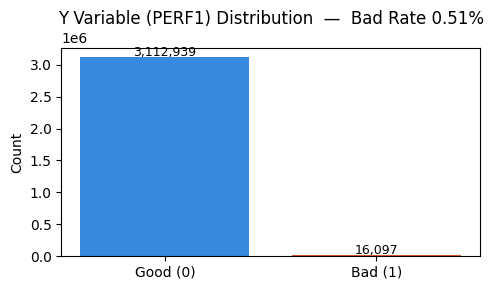


제외 후 shape : (3129036, 149)

[독립변수 그룹별 건수]
  카드(C) : 43개
  대출(L) : 49개
  자산(U) : 14개
  연체(D) : 29개
  기타(A) : 11개
  합계  : 146개

[결측률 상위 20개 변수]
              결측률(%)     결측건수
D10147000  94.475647  2956177
D10155000  94.458773  2955649
AL0C00004  88.250758  2761398
AL0C00002  88.013369  2753970
AL0C00001  88.011675  2753917
AL0C00005  88.004996  2753708
AL0C00003  88.004452  2753691
C1L120049  74.115766  2319109
C1L120272  74.113817  2319048
C1L120196  74.102983  2318709
C1L120270  74.100681  2318637
C1L120012  74.079525  2317975
C1L120024  74.077479  2317911
C1L120001  74.059870  2317360
C1L120171  74.037531  2316661
U81103010  66.685363  2086609
AS120G001  56.769082  1776325
C1L120292  54.781409  1714130
C1L120250  54.260034  1697816
C1L120237  54.243639  1697303

결측률 70% 초과 변수 : 15개
['D10147000', 'D10155000', 'AL0C00004', 'AL0C00002', 'AL0C00001', 'AL0C00005', 'AL0C00003', 'C1L120049', 'C1L120272', 'C1L120196', 'C1L120270', 'C1L120012', 'C1L120024', 'C1L120001', 'C1L120171']

[Train /

In [3]:
# ============================================================
# 01_data_preprocessing_y_label
# 개인CB 합성데이터 전처리 및 Y변수 정의
# ============================================================

# %% [1] 라이브러리
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib
matplotlib.rcParams['font.family'] = 'DejaVu Sans'
matplotlib.rcParams['axes.unicode_minus'] = False

# %% [2] 데이터 로드
df = pd.read_csv(
    'data/aihub_raw/202112_개인CB.csv',
    encoding='utf-8',       # 깨질 경우 'cp949' 로 변경
    low_memory=False
)
print(f"원본 shape : {df.shape}")
print(f"컬럼 수    : {df.shape[1]}")
df.head(2)

# %% [3] 특이값 → NaN 치환
# AI Hub 개인CB 특이값 코드
MISSING_CODES = [8888888.8, 888888888, -9, -99999999, 9999999, 99999999]

df.replace(MISSING_CODES, np.nan, inplace=True)
print("특이값 NaN 치환 완료")

# %% [4] Y변수 정의
# PERF1 : 신청일로부터 12개월 내 90일 이상 연체경험 여부
# 0 → 우량, 1 → 불량, NaN → 분석 제외

print("\n[PERF1 분포 - 치환 전]")
print(df['PERF1'].value_counts(dropna=False))

# PERF 결측(-9, -99999999 는 위에서 이미 NaN 처리됨)
df_model = df.dropna(subset=['PERF1']).copy()
df_model['Y'] = df_model['PERF1'].astype(int)

print(f"\n분석 제외(PERF1 NaN) : {len(df) - len(df_model):,}건")
print(f"분석 대상            : {len(df_model):,}건")

# %% [5] 불량률 확인
n_total = len(df_model)
n_bad   = df_model['Y'].sum()
n_good  = n_total - n_bad
bad_rate = n_bad / n_total * 100

print(f"\n{'='*40}")
print(f"전체   : {n_total:>10,}건")
print(f"우량(0): {n_good:>10,}건  ({100-bad_rate:.2f}%)")
print(f"불량(1): {n_bad:>10,}건  ({bad_rate:.2f}%)")
print(f"{'='*40}")

# 시각화
fig, ax = plt.subplots(figsize=(5, 3))
ax.bar(['Good (0)', 'Bad (1)'], [n_good, n_bad], color=['#378ADD', '#D85A30'])
ax.set_title(f'Y Variable (PERF1) Distribution  —  Bad Rate {bad_rate:.2f}%')
ax.set_ylabel('Count')
for i, v in enumerate([n_good, n_bad]):
    ax.text(i, v + n_total*0.005, f'{v:,}', ha='center', fontsize=9)
plt.tight_layout()
plt.savefig('outputs/figures/01_y_distribution.png', dpi=150)
plt.show()

# %% [6] 제외 컬럼 정의
DROP_COLS = [
    'STDT',        # 기준년월 (식별자)
    'ID',          # 대체Key (식별자)
    'SCORE',       # KCB 기존 스코어 → 정답 누설
    'SCORE_6M',    # 6개월 후 스코어 → 정답 누설
    'PERF1',       # Y변수 원본 (Y로 대체)
    'PERF2',       # 30일 연체 (Y후보 → 제외)
    'PERF3',       # 신규대출 발생 (연체 아님)
    'PERF4',       # 60일 연체 (Y후보 → 제외)
    'D10175000',   # 최장연체일수 → Y와 직접 연동 (누설)
]

df_model.drop(columns=DROP_COLS, inplace=True)
print(f"\n제외 후 shape : {df_model.shape}")

# %% [7] 독립변수 그룹 분류 확인
feature_cols = [c for c in df_model.columns if c not in ['Y', 'GENDER', 'AGE_BAND']]

groups = {
    '카드(C)'  : [c for c in feature_cols if c.startswith('C')],
    '대출(L)'  : [c for c in feature_cols if c.startswith('L')],
    '자산(U)'  : [c for c in feature_cols if c.startswith('U')],
    '연체(D)'  : [c for c in feature_cols if c.startswith('D')],
    '기타(A)'  : [c for c in feature_cols if c.startswith('A')],
}

print("\n[독립변수 그룹별 건수]")
for g, cols in groups.items():
    print(f"  {g} : {len(cols)}개")
print(f"  합계  : {sum(len(v) for v in groups.values())}개")

# %% [8] 결측률 요약
missing = df_model[feature_cols].isnull().mean() * 100
missing_summary = pd.DataFrame({
    '결측률(%)': missing,
    '결측건수' : df_model[feature_cols].isnull().sum()
}).sort_values('결측률(%)', ascending=False)

print("\n[결측률 상위 20개 변수]")
print(missing_summary.head(20).to_string())

# 결측률 70% 초과 변수 → 제거 권고 목록
high_missing = missing_summary[missing_summary['결측률(%)'] > 70].index.tolist()
print(f"\n결측률 70% 초과 변수 : {len(high_missing)}개")
if high_missing:
    print(high_missing)

# %% [9] Train / Test 분할 (70 / 30)
from sklearn.model_selection import train_test_split

X = df_model.drop(columns=['Y', 'GENDER', 'AGE_BAND'])
y = df_model['Y']

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.3,
    random_state=42,
    stratify=y          # 불량률 비율 유지
)

print(f"\n[Train / Test 분할]")
print(f"Train : {len(X_train):,}건  (불량률 {y_train.mean()*100:.2f}%)")
print(f"Test  : {len(X_test):,}건  (불량률 {y_test.mean()*100:.2f}%)")

# %% [10] 저장
df_model.to_csv('data/aihub_raw/01_preprocessed.csv', index=False, encoding='utf-8-sig')
X_train.join(y_train).to_csv('data/aihub_raw/01_train.csv', index=False, encoding='utf-8-sig')
X_test.join(y_test).to_csv('data/aihub_raw/01_test.csv',  index=False, encoding='utf-8-sig')

print("\n저장 완료:")
print("  data/aihub_raw/01_preprocessed.csv")
print("  data/aihub_raw/01_train.csv")
print("  data/aihub_raw/01_test.csv")